In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
## Read table
fname = 'vetting-v01'
fpath = f'mnt/tess/labels/{fname}.csv'

second_f=True
get_rid_of_n=True

if second_f:
    fname_extra_objects = 'vetting-new-events-withfilenames'
    fpath_extra_objects=f'mnt/tess/labels/{fname_extra_objects}.csv'



# Read CSVs and set 'Astro ID' as index
all_table = pd.read_csv(fpath, index_col='Astro ID', low_memory=False)
print('Original table shape:', all_table.shape)

if second_f:
    long_per_table = pd.read_csv(fpath_extra_objects, index_col='Astro ID', low_memory=False)
    print('Long period table shape:', long_per_table.shape)

    all_table_2=pd.concat([all_table, long_per_table], ignore_index=False)

    all_table=all_table_2
    print('Table shape after adding events from the second spreadsheet:', all_table.shape)

Original table shape: (9344, 32)
Long period table shape: (1647, 59)
Table shape after adding events from the second spreadsheet: (10991, 60)


In [ ]:
orig_table=all_table.copy()

In [ ]:
# how many orig_table['Final'] are empty
# Count the number of empty 'Final' entries

empty_final_count = all_table['Final'].isna().sum()
print(f"Number of empty 'Final' entries: {empty_final_count}")


Number of empty 'Final' entries: 5351


In [ ]:
all_table.columns

Index(['Dec', 'Decision', 'Depth', 'Dur', 'Epoc', 'File', 'Final', 'Per', 'RA',
       'SMass', 'SRad', 'SRadEst', 'TIC ID', 'Tmag', 'as', 'ch', 'disp_b',
       'disp_e', 'disp_j', 'disp_n', 'disp_p', 'disp_t', 'disp_u', 'dm', 'et',
       'md', 'mk'],
      dtype='object')

In [ ]:
## Rename or drop columns
# all_table.drop(columns=['Split'])
all_table = all_table.rename(columns={'filename': 'File',
                                      'Period': 'Per',
                                      'Duration': 'Dur',
                                      'Transit_Depth': 'Depth',
                                      'star_rad': 'SRad',
                                      'star_rad_est': 'SRadEst',
                                      'star_mass': 'SMass',})

In [ ]:
## Make label columns
disps = ['e', 'p', 'n', 'b', 't', 'u', 'j']
users = ['mk', 'ch', 'et', 'md', 'as', 'dm', 'Tansu', 'Shishir']
for d in disps:
    all_table[f'disp_{d}'] = 0

# Set all TOIs commented with "CP", "PC", or "KP" with the label 'pu'
tois_planet_mask = (all_table['comment'].str.contains("(PC)", regex=False).astype(bool) | all_table['comment'].str.contains("(CP)", regex=False).astype((bool)) | all_table['comment'].str.contains("(KP)", regex=False).astype((bool)))


# # Print mismatches - not labelled planet by vetters, but is a TOI labelled KP, CP or PC (known planet, confirmed planet, planetary candidate)
print('Mismatches between TOI comment and vetting labels', all_table[tois_planet_mask][(all_table[tois_planet_mask]['Final'] != 'pt') & (~all_table[tois_planet_mask]['Final'].isna())]['TIC ID'])
print('Number of mismatches:', len(all_table[tois_planet_mask][(all_table[tois_planet_mask]['Final'] != 'pt') & (~all_table[tois_planet_mask]['Final'].isna())]))

# print('Mismatches between TOI comment and vetting labels',
#       all_table[tois_planet_mask][(~all_table[tois_planet_mask]['Final'].isin(['pt', 'pu'])) &
#                                     (~all_table[tois_planet_mask]['Final'].isna())]['TIC ID'])


all_table.loc[tois_planet_mask, 'Final'] = 'pu'

if second_f:
    # Correct label 'EB' into 'eb', 'IS' into 'i' and V into 'jj'
    all_table.loc[all_table['Final'] == 'EB', 'Final'] = 'eb'
    all_table.loc[all_table['Final'] == 'IS', 'Final'] = 'i'
    all_table.loc[all_table['Final'] == 'V', 'Final'] = 'jj'

    # if label is O set as 'jj'
    all_table.loc[all_table['Final'] == 'O', 'Final'] = 'jj'

#Note: The new

## Set labels
def set_labels(row):
    a = ~row.isna()
    if row['Final'] == 'i':
        # skip objects labeled as "inside the star"
        return row
    if a['Final']:
        row[f'disp_{row["Final"][0]}'] = 1
        row[f'disp_{row["Final"][1]}'] = 1

    else:
        for user in users:
            if a[user] and row[user]:
                row[f'disp_{row[user][0]}'] += 1
                row[f'disp_{row[user][1]}'] += 1

    if isinstance(row['Final'], str) and len(row['Final']) > 2:
        row['Final'] = row['Final'][:2]  # truncate to first two characters for consistency in case the label had 3 letters etc

    return row

all_table = all_table.apply(set_labels, axis=1)

Mismatches between TOI comment and vetting labels Astro ID
966       300217120
1260     1551168743
1261     1551168745
1270     1716106614
1447      391925531
            ...    
10504     341405597
10526     220524097
10535     382521776
10646     257467784
10764     230013442
Name: TIC ID, Length: 125, dtype: int64
Number of mismatches: 125


In [ ]:
## Add more B, J, N labels from Astronet-triage into training set to J class

print('Initial table shape:', all_table.shape)
print('---- Adding more B, J, N labels from Astronet triage ----')


fpath_triage = 'mnt/tess/astronet/tces-v14-all.csv'
# fpath_triage = 'mnt/tess/astronet/tces-v14-all.csv'

table_triage = pd.read_csv(fpath_triage, header=0, low_memory=False).set_index('Astro ID')

# Adding junk examples taking junk (J), contact binaries (B) and not sure (N) from astronet triage dataset
junk_df = table_triage[(table_triage['Final'] == 'J') & (table_triage['File'].str.contains('mk_'))]

print('Junk examples:', junk_df.shape)

# Add more B examples
b_df = table_triage[(table_triage['Final'] == 'B') & (table_triage['File'].str.contains('mk_'))]
print('B examples:', b_df.shape)
# Add more N examples
n_df = table_triage[(table_triage['Final'] == 'N') & (table_triage['File'].str.contains('mk_'))]
print('N examples:', n_df.shape)


print('Total junk examples added (B,N treated as junk):', junk_df.shape[0] + b_df.shape[0] + n_df.shape[0])

more_bjn_labels = pd.concat([junk_df, b_df, n_df], ignore_index=False)
more_bjn_labels['disp_e'] = 0
more_bjn_labels['disp_p'] = 0
more_bjn_labels['disp_n'] = 0
more_bjn_labels['disp_b'] = 0
more_bjn_labels['disp_t'] = 0
more_bjn_labels['disp_u'] = 0
more_bjn_labels['disp_j'] = 1

more_bjn_labels['Final'] = 'jj'

new_columns = all_table.keys().intersection(more_bjn_labels.keys()) # Get only overlapping columns from all_table and more_bjn_labels: Index(['TIC ID', 'Final', 'Decision', 'mk', 'ch', 'et', 'md', 'as', 'dm', 'Split', 'RA', 'Dec', 'Tmag', 'Epoc', 'Per', 'Dur', 'Depth', 'SRad', 'SMass', 'SRadEst', 'File', 'disp_e', 'disp_p', 'disp_n', 'disp_b', 'disp_t', 'disp_u', 'disp_j'])

all_table = pd.concat([all_table[new_columns], more_bjn_labels[new_columns]]) # Add 1000 Bs, 1000 Js, and 500 Ns into J class of all_table

print('Final table shape after adding B, J, N labels from Astronet triage:', all_table.shape)


Initial table shape: (12588, 27)
---- Adding more B, J, N labels from Astronet triage ----
Junk examples: (1675, 32)
B examples: (70, 32)
N examples: (6, 32)
Total junk examples added 1751
Final table shape after adding B, J, N labels from Astronet triage: (14339, 27)


In [ ]:
print(f'Total entries: {len(all_table)}')

## And skip bad rows that have NaN in File', 'Per', 'Dur', 'Depth', or 'Tmag'
print("Skipping these TICs:", all_table[all_table[['File', 'Per', 'Dur', 'Depth', 'Tmag']].isna().any(axis=1)]['TIC ID'])
all_table = all_table[~all_table[['File', 'Per', 'Dur', 'Depth', 'Tmag']].isna().any(axis=1)]
print(f'Total after removing rows with missing File, Per, Dur, Depth, or Tmag: {len(all_table)}')


Total entries: 12742
Skipping these TICs: Astro ID
966       300217120
1260     1551168743
1261     1551168745
1270     1716106614
1447      391925531
            ...    
10698     272125414
10787     422912527
10791      83181153
10875     137685450
10982      44161614
Name: TIC ID, Length: 154, dtype: int64
Total after removing rows with missing File, Per, Dur, Depth, or Tmag: 12588


In [ ]:
def assign_final_labels(data):
    # Create a copy to avoid modifying the original
    df = data.copy()

    # Get rows without a Final label
    mask_missing_final = df['Final'].isna()
    rows_to_update = df[mask_missing_final].index

    # Define the column groupings
    first_letter_cols = ['disp_e', 'disp_j', 'disp_n', 'disp_p']
    second_letter_cols = ['disp_t', 'disp_b', 'disp_u']

    # Count how many rows we'll be updating
    print(f"Assigning 'Final' labels to {len(rows_to_update)} rows...")

    for idx in rows_to_update:
        # For first letter: Get votes for e, j, n, p
        first_letter_votes = {col[-1]: df.loc[idx, col] for col in first_letter_cols}
        max_first_vote = max(first_letter_votes.values())

        # Check if there's a tie or no votes for first letter
        max_vote_disps = [d for d, count in first_letter_votes.items() if count == max_first_vote]
        if len(max_vote_disps) > 1 or max_first_vote == 0:
            first_letter = 'p'  # Default to 'p' in case of tie
        else:
            first_letter = max_vote_disps[0]

        # For second letter: Get votes for t, b, u
        second_letter_votes = {col[-1]: df.loc[idx, col] for col in second_letter_cols}
        max_second_vote = max(second_letter_votes.values())

        # Check if there's a tie or no votes for second letter
        max_vote_second_letters = [l for l, count in second_letter_votes.items() if count == max_second_vote]
        if len(max_vote_second_letters) > 1 or max_second_vote == 0:
            second_letter = 'u'  # Default to 'u' in case of tie
        else:
            second_letter = max_vote_second_letters[0]

        # Assign the final label
        df.loc[idx, 'Final'] = first_letter + second_letter

    print(f"Finished assigning 'Final' labels.")

    # Show statistics of new Final values
    if len(rows_to_update) > 0:
        new_finals = df.loc[rows_to_update, 'Final'].value_counts()
        print("\nDistribution of newly assigned 'Final' values:")
        for label, count in new_finals.items():
            print(f"{label}: {count} ({count/len(rows_to_update)*100:.1f}%)")

    return df

# Apply the function to assign final labels
all_table_updated = assign_final_labels(all_table)

# Check how many entries now have a Final value
print("\nAfter update:")
print(f"Total number of entries with a Final value: {all_table_updated['Final'].notna().sum()}")
print(f"Number of entries without a Final value: {all_table_updated['Final'].isna().sum()}")

# Show the updated distribution of Final values
print("\nUpdated distribution of Final values:")
print(all_table_updated['Final'].value_counts())

all_table=all_table_updated.copy()

Assigning 'Final' labels to 1292 rows...
Finished assigning 'Final' labels.

Distribution of newly assigned 'Final' values:
pu: 1216 (94.1%)
eb: 27 (2.1%)
et: 24 (1.9%)
pt: 13 (1.0%)
eu: 7 (0.5%)
pb: 4 (0.3%)
nt: 1 (0.1%)

After update:
Total number of entries with a Final value: 12588
Number of entries without a Final value: 0

Updated distribution of Final values:
Final
pu    6935
eb    2134
jj    1974
et    1195
pt     139
pb      84
eu      67
i       28
nu      12
nt      10
nb       8
ub       1
#R       1
Name: count, dtype: int64


In [ ]:
#Optional: get rid of the n label

if get_rid_of_n:
    #Check which entries have 'Final' that starts with 'n' and remove those entries from all_table
    print("Removing entries with 'Final' starting with 'n'...")
    n_mask = all_table['Final'].str.startswith('n', na=False)
    n_count = n_mask.sum()
    print(f"Number of entries to remove: {n_count}")
    all_table = all_table[~n_mask]
    # Check the final shape of the table
    print(f"Final table shape after removing 'n' entries: {all_table.shape}")
# Final check of the distribution of Final values
print("\nFinal distribution of 'Final' values after optional removal of 'n':")
print(all_table['Final'].value_counts())

In [ ]:
(orig_table['Final']=='#R').sum(), long_per_table[long_per_table['Final']=='#R'].shape[0]

Label distribution etc

In [ ]:
# Define the specific disposition columns to analyze
selected_disp_columns = ['disp_e', 'disp_j', 'disp_n', 'disp_p']

# Calculate total votes per row for just these categories
all_table['selected_total_votes'] = all_table[selected_disp_columns].sum(axis=1)

# Overall statistics
print("Vote count statistics across selected disposition categories (e, j, n, p):")
print(all_table['selected_total_votes'].describe())

# Distribution of vote counts
vote_distribution = all_table['selected_total_votes'].value_counts().sort_index()
print("\nDistribution of total votes per instance (for selected categories):")
print(vote_distribution)

# Compare instances with and without Final values
with_final = all_table[~all_table['Final'].isna()]
without_final = all_table[all_table['Final'].isna()]

print("\nVote count statistics for instances WITH a Final value:")
print(with_final['selected_total_votes'].describe())

print("\nVote count statistics for instances WITHOUT a Final value:")
print(without_final['selected_total_votes'].describe())

# Optional: Calculate percentage of instances with each vote count
print("\nPercentage of instances by vote count (for selected categories):")
for votes, count in vote_distribution.items():
    pct = count / len(all_table) * 100
    print(f"{votes} votes: {count} instances ({pct:.1f}%)")

# Optional: Visualize with a histogram
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(all_table['selected_total_votes'],
         bins=range(0, max(all_table['selected_total_votes'])+2),
         align='left', alpha=0.7)
plt.xlabel('Total Votes per Instance (e, j, n, p categories)')
plt.ylabel('Number of Instances')
plt.title('Distribution of Vote Counts for Selected Disposition Categories')
plt.grid(axis='y', alpha=0.75)
plt.xticks(range(0, max(all_table['selected_total_votes'])+1))
plt.show()

/tmp/ipykernel_35765/2792134519.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


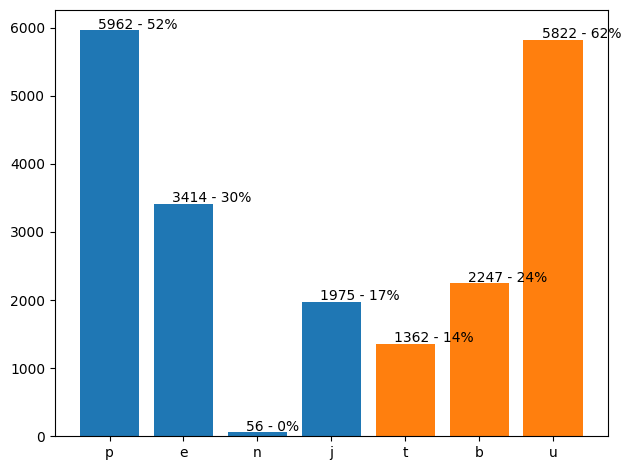

In [ ]:
# Plot label distribution

from matplotlib import pyplot as plt
labels = ['p', 'e', 'n', 'j']
labels2 = ['t', 'b', 'u']

counts = [sum(all_table['disp_{}'.format(l)] > 0) for l in labels]
counts2 = [sum(all_table['disp_{}'.format(l)] > 0) for l in labels2]

plt.figure()
ax = plt.bar(labels, counts)
for i in range(len(labels)):
    b = ax[i]
    height = b.get_height()
    x, y = b.get_xy()
    plt.annotate(
        '{} - {:.0%}'.format(counts[i], counts[i] / sum(counts)),
        (x + 0.25, y + height + 20))
plt.tight_layout()

# plt.figure()
ax2 = plt.bar(labels2, counts2)
for i in range(len(labels2)):
    b = ax2[i]
    height = b.get_height()
    x, y = b.get_xy()
    plt.annotate(
        '{} - {:.0%}'.format(counts2[i], counts2[i] / sum(counts2)),
        (x + 0.25, y + height + 20))
plt.tight_layout()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Extract the first letter of the Final column
all_table['first_letter'] = all_table['Final'].str[0]

# Count the occurrences of each first letter
first_letter_counts = all_table['first_letter'].value_counts().reindex(['p', 'e', 'j', 'n'])

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=first_letter_counts.index, y=first_letter_counts.values,
            palette=['#ff7f0e', '#2ca02c', '#1f77b4', '#d62728'])

# Add labels and title
plt.title('Distribution of Disposition Classes (First Letter of Final)', fontsize=16)
plt.xlabel('Disposition Class', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Add data labels on top of each bar
for i, count in enumerate(first_letter_counts):
    plt.text(i, count + (max(first_letter_counts) * 0.01),
             f'{count}\n({count/len(all_table)*100:.1f}%)',
             ha='center', fontsize=12)

# Add a legend with explanations
labels = {
    'p': 'Planet Candidate',
    'e': 'Eclipsing Binary',
    'j': 'Junk/Systematic',
    'n': 'Not Transit-Like'
}
handles = [plt.Rectangle((0,0),1,1, color=c) for c in ['#ff7f0e', '#2ca02c', '#1f77b4', '#d62728']]
plt.legend(handles, [f"{k}: {v}" for k, v in labels.items()], loc='upper right')

plt.tight_layout()
plt.show()

Cross-validation split

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import StratifiedKFold

X=all_table.copy() # Use the final table with all the data

# Assume X is your full DataFrame containing both features and the 'Final' label column.
n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

# Define file naming parameters
# fname = "your_fname"  # Update this with your identifier
NAME = "tois-triageJs-nocentroid-newTOIs2025-v3"

# Save the complete dataset (optional)
all_csv_path = f"mnt/tess/astronet/tces-{fname}-{NAME}-all.csv"
if os.path.exists(all_csv_path):
    print("*****\nAlready saved TCE csv files. Overwriting the existing file.\n*****")
    X.to_csv(all_csv_path, index=False)
else:
    X.to_csv(all_csv_path, index=False)

# Perform stratified k-fold splitting and save each fold's train/validation splits
fold = 1

for train_idx, val_idx in skf.split(X, X['Final']):
    train_df = X.iloc[train_idx]
    val_df = X.iloc[val_idx]

    print(f"Fold {fold}: train size = {len(train_df)}, val size = {len(val_df)}")

    train_csv_path = f"mnt/tess/astronet/crossvalcsvs/tces-{fname}-{NAME}-train_fold{fold}.csv"
    val_csv_path = f"mnt/tess/astronet/crossvalcsvs/tces-{fname}-{NAME}-val_fold{fold}.csv"

    train_df.to_csv(train_csv_path, index=False)
    val_df.to_csv(val_csv_path, index=False)

    fold += 1


Train-val-test split

In [ ]:


## Train-test split
t_train, t_test = train_test_split(all_table, test_size=0.1, random_state=42)
t_train, t_val = train_test_split(t_train, test_size=1./9, random_state=42)

## Print sizes of arrays and print duplicate counts
print(f'Split sizes. Train: {len(t_train)}; Valid: {len(t_val)}; Test: {len(t_test)}')
print(f'Duplicate TICs: {len(all_table.index.values) - len(set(all_table.index.values))}')
print('Splits')
print('  train:', len(t_train))
print('  val:', len(t_val))
print('  test:', len(t_test))

## Check label arrays
assert not any((t_train['disp_e'] + t_train['disp_p']+ t_train['disp_n'] + t_train['disp_b'] + t_train['disp_t'] + t_train['disp_u'] + t_train['disp_j']) == 0)
assert not any((t_val['disp_e'] + t_val['disp_p']+ t_val['disp_n'] + t_val['disp_b'] + t_val['disp_t'] + t_val['disp_u']+ t_val['disp_j']) == 0)
assert not any((t_test['disp_e'] + t_test['disp_p']+ t_test['disp_n'] + t_test['disp_b'] + t_test['disp_t'] + t_test['disp_u'] + t_test['disp_j']) == 0)

# ## Save train, test, and validation csv files
# NAME = "tois-triageJs-nocentroid" # [including tois as pt, including B,J,N labels from Astronet-triage, and without centroid data]
# NAME = "tois-triageJs-nocentroid" # [including tois as pt, including B,J,N labels from Astronet-triage, and without centroid data, and removing TICs with centroid distance > 20 arcs]
NAME = "tois-triageJs-nocentroid-long" # [including tois as pt, including B,J,N labels from Astronet-triage, and without centroid data, and removing TICs with centroid distance > 20 arcs. Including new long period events (Feb 2025)]



if os.path.exists(f'../mnt/tess/astronet/tces-{fname}-{NAME}-all.csv'):
    print("*****\nAlready saved TCE csv files. Are you sure you want to overwrite them?\n*****")
else:
    pass
t_train.to_csv(f'../mnt/tess/astronet/tces-{fname}-{NAME}-train.csv')
t_val.to_csv(f'../mnt/tess/astronet/tces-{fname}-{NAME}-val.csv')
t_test.to_csv(f'../mnt/tess/astronet/tces-{fname}-{NAME}-test.csv')
all_table.to_csv(f'../mnt/tess/astronet/tces-{fname}-{NAME}-all.csv')
